# Яндекс-Афиша: исследовательский анализ данных по изменению пользовательских предпочтений и популярности событий осенью 2024г.

### Цели и задачи проекта

**Цель:** провести исследовательский анализ изменения пользовательских предпочтений и популярности событий сервиса Яндекс-Афиша осенью 2024 года

**Задачи:**
1. Загрузить данные и познакомиться с их содержанием.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
 - Изучить распределения заказов по сегментам и их сезонные изменения
 - Изучить осеннюю активность пользователей
 - Изучить популярные события и партнёров
4. Провести статистический анализ данных групп пользователей мобильных и стационарных устройств
 - Анализ среднего количества заказов на пользователя в группах
 - Анализ среднего времени между заказами в группах
5. Сформулировать выводы по проведенному анализу.

### Содержимое проекта

---
1. [Загрузка данных и знакомство с ними](#загрузка-данных)
2. [Предобработка данных](#предобработка-данных)
3. [Исследовательский анализ данных](#исследовательский-анализ)
- 3.1 [Анализ распределения заказов по сегментам и их сезонные изменения](#анализ-распределения)
- 3.2 [Осенняя активность пользователей](#осенняя-активность)
- 3.3 [Популярные события и партнёры](#популярные)
4. [Статистический анализ данных](#статистический)
5. [Итоговый вывод](#итоговый-вывод)
- 5.1 [Основные выводы](#основные-выводы)
- 5.2 [Рекомендации](#рекомендации)

<a id="загрузка-данных"></a>
## 1. Загрузка данных и знакомство с ними

Загрузим библиотеки и датасеты `final_tickets_orders_df.csv` и `final_tickets_events_df.csv`, а также дополнительный датасет `final_tickets_tenge_df.csv`. Данные датасетов сохраним в переменные `orders_df`, `events_df` и `tenge_df`, соответственно

In [1]:
# Импортируем библиотеку pandas для анализа данных
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотеки для статистического анализа
from statsmodels.stats.power import TTestIndPower
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

In [2]:
# Выгрузим данные в переменные: orders_df, events_df и tenge_df

orders_df = pd.read_csv('/datasets/final_tickets_orders_df.csv', low_memory=False)
events_df = pd.read_csv('/datasets/final_tickets_events_df.csv', low_memory=False)
tenge_df = pd.read_csv('/datasets/final_tickets_tenge_df.csv', low_memory=False)

Изучим датасет `orders_df` методами *info()* и *head()*

In [3]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [4]:
orders_df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


Предварительные выводы о датасете `orders_df`:

- Датасет `orders_df` содержит **290849 строк** и **14 столбцов**. 
- Названия столбцов приведены к общему стилю. 
- Столбцы с датами `created_dt_msk` и `created_ts_msk` хранятся в типе данных **object**. Их необходимо привести к типу **datetime64**.
- Столбцы `order_id`, `event_id`, `age_limit`, `tickets_count` - в типе данных **int64**. Размеренность данных этих столбцов можно оптимизировать, так как они содержат небольшие целочисленные значения.
- Столбец `days_since_prev` хранятся в типе **float64**. Для него больше подойдет тип **int**, так как число дней - это всегда целое число.
- **Пропуски** содержатся только в столбце `days_since_prev`. Остальные столбцы следует проверить на значения-индикаторы, которые укажут на отсутствие данных. 
- Значения в столбцах соответствуют описанию.

Изучим датасет `events_df` методами *info()* и *head()*

In [5]:
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [6]:
events_df.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


Предварительные выводы о датасете `events_df`:

- Датасет `events_df` содержит **22427 строк** и **11 столбцов**. 
- Названия столбцов приведены к общему стилю. 
- Столбцы `event_id`, `city_id`, `venue_id` - в типе данных **int64**. Размеренность данных этих столбцов можно оптимизировать, так как они содержат небольшие целочисленные значения.
- **Пропуски** в даннных отсутствуют.
- Значения в столбцах соответствуют описанию.

Изучим датасет `tenge_df` методами *info()* и *head()*

In [7]:
tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [8]:
tenge_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Информация о датасете `tenge_df`:

- Датасет содержит **357 строк** и **4 столбца**. 
- Названия столбцов приведены к общему стилю.
- Столбец с датами `data` хранится в типе данных **object**. Его следует привести к типу **datetime64**.
- Столбец `nominal` - в типе данных **int64**. Размеренность данных этого столбца можно оптимизировать, так как в нем содержатся небольшие целочисленные значения.
- **Пропуски** в даннных отсутствуют.
- Значения в столбцах соответствуют описанию.

### Промежуточный вывод

Первичное знакомство показывает, что данные для анализа предоставлены в небольшом объеме, не превышающим 65 MB. Данные соответствуют описанию и выглядят корректно. Пропуски в данных практически отсутствуют, за исключением столбца `days_since_prev`, как и было заявлено в исходном описании. Возможно, их потребуется заменить на индикаторы. Часть типов данных требует оптимизации по выбранному типу хранения и изменения размеренности. Данные следует проверить на наличие явных и неявных дубликатов.

### Подготовка единого датафрейма

Для удобства работы с данными, объединим их в общий датафрейм `tickets_df`:

In [9]:
# Объединим датасеты orders_df и events_df через inner, так как для анализа нужна полная информация
tickets_df1 = orders_df.merge(events_df, on='event_id', how='inner')

In [10]:
# Получившийся датасет tickets_df1 объединим с доп. датасетом tenge_df для дальнейшего приведения валюты к единому виду
tickets_df = tickets_df1.merge(tenge_df, left_on='created_dt_msk', right_on='data', how='left')

In [11]:
tickets_df.info()

lens_of_start = len(tickets_df)
display(f'Количество строк исходного датафрейма: {lens_of_start}')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290611 non-null  int64  
 1   user_id                 290611 non-null  object 
 2   created_dt_msk          290611 non-null  object 
 3   created_ts_msk          290611 non-null  object 
 4   event_id                290611 non-null  int64  
 5   cinema_circuit          290611 non-null  object 
 6   age_limit               290611 non-null  int64  
 7   currency_code           290611 non-null  object 
 8   device_type_canonical   290611 non-null  object 
 9   revenue                 290611 non-null  float64
 10  service_name            290611 non-null  object 
 11  tickets_count           290611 non-null  int64  
 12  total                   290611 non-null  float64
 13  days_since_prev         268698 non-null  float64
 14  event_name          

'Количество строк исходного датафрейма: 290611'

Данные объеденены в общий датасет `tickets_df`. Полученный датасет содержит **290611** строк и **28** столбцов, в объеме **64.3+ MB**

<a id="предобработка-данных"></a>
## 2. Предобработка данных

### 2.1 Пропуски в данных

В датасете `tickets_df` пропуски содержатся только в столбце `days_since_prev`. Изучим значения этого столбца, подберем индикатор и заменим пропущенные значения для дальнейшей обработки

In [12]:
# Выведем уникальные значения столбца
tickets_df['days_since_prev'].unique()

array([ nan,   0.,   3.,   7.,   1.,  16.,   2.,   5.,  14.,   9.,  75.,
        22.,  56.,  12.,  15.,  11.,   8.,  10.,   4.,  40.,  58.,  50.,
         6.,  32.,  25.,  24.,  43.,  13.,  66.,  83.,  78.,  19.,  31.,
       129.,  26.,  48.,  28.,  21.,  52., 107.,  89.,  42.,  23.,  65.,
        20.,  18.,  64.,  85.,  39.,  74.,  27.,  82.,  47.,  38.,  95.,
        37.,  67., 104.,  96.,  41.,  29.,  34.,  55.,  61.,  88., 116.,
        84.,  62., 132.,  92.,  98.,  30., 108.,  45.,  59.,  17.,  35.,
       109., 111.,  54.,  36.,  44.,  33.,  70.,  57., 113., 100.,  72.,
       102.,  80.,  71.,  53.,  73.,  76., 114.,  49.,  51.,  81.,  63.,
        86., 123.,  77.,  46., 101.,  79.,  68.,  91., 126., 112., 134.,
       117.,  90.,  99., 106., 120.,  87., 128.,  97.,  93.,  69.,  60.,
       144., 125., 115., 119., 122., 110., 133., 124., 138., 136., 118.,
        94., 105., 143., 137., 135., 121., 103., 142., 131., 147., 139.,
       127., 141., 145., 146., 148., 130., 140.])

Столбец `days_since_prev` показывает количество дней с предыдущей покупки для каждого пользователя. Разброс значений от 0 до 150. Отрицательные значения отсутствуют, следовательно индикатором можно сделать значение **-1**

In [13]:
# Заменим пропуски на значение-индикатор методом filna() и приведем к типу данных int
tickets_df['days_since_prev'] = tickets_df['days_since_prev'].fillna(-1)
tickets_df['days_since_prev'] = tickets_df['days_since_prev'].astype('int64', errors='ignore')

In [14]:
# Убедимся, что в датафрейме не осталось пропущенных значений
display(tickets_df.isna().sum())

order_id                  0
user_id                   0
created_dt_msk            0
created_ts_msk            0
event_id                  0
cinema_circuit            0
age_limit                 0
currency_code             0
device_type_canonical     0
revenue                   0
service_name              0
tickets_count             0
total                     0
days_since_prev           0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
data                      0
nominal                   0
curs                      0
cdx                       0
dtype: int64

### 2.2 Оптимизация типов данных

Столбцы с датами `created_dt_msk` и `created_ts_msk` из типа **object** приведем к типу данных **datetime64**.

In [15]:
tickets_df[['created_dt_msk', 'created_ts_msk']] = tickets_df[['created_dt_msk', 'created_ts_msk']].astype('datetime64')

# Выводим тип данных для проверки
display(tickets_df[['created_dt_msk', 'created_ts_msk']].dtypes)

created_dt_msk    datetime64[ns]
created_ts_msk    datetime64[ns]
dtype: object

Типы данных 7 столбцов (`order_id`, `event_id`, `city_id`, `venue_id`, `age_limit`, `tickets_count`, `days_since_prev`) можно оптимизировать, с помощью понижения разряда бит

In [16]:
for column in ['order_id', 'event_id', 'city_id', 'venue_id', 'age_limit', 'tickets_count', 'days_since_prev']:
    tickets_df[column] = pd.to_numeric(tickets_df[column], downcast='integer')
    
display(tickets_df[['order_id', 'event_id', 'city_id', 'venue_id', 'age_limit', 'tickets_count', 'days_since_prev']].dtypes)

order_id           int32
event_id           int32
city_id            int32
venue_id           int16
age_limit           int8
tickets_count       int8
days_since_prev    int16
dtype: object

### 2.3 Явные и неявные дубликаты

In [17]:
# Проверим наличие полных дубликатов в датафрейме tickets_df
tickets_df.duplicated().sum()

0

In [18]:
# Выведем количество уникальных значений каждого столбца
display(tickets_df.nunique())

order_id                  290611
user_id                    21933
created_dt_msk               153
created_ts_msk            280753
event_id                   22427
cinema_circuit                 6
age_limit                      5
currency_code                  2
device_type_canonical          2
revenue                    42522
service_name                  36
tickets_count                 22
total                      55458
days_since_prev              150
event_name                 15248
event_type_description        20
event_type_main                7
organizers                  4293
region_name                   81
city_name                    352
city_id                      353
venue_id                    3225
venue_name                  3217
venue_address               3225
data                         153
nominal                        1
curs                         108
cdx                            1
dtype: int64

In [19]:
# Проверяем уникальные значения в столбцах с небольшим числом уникальных значений
for column in ['cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical', 'tickets_count', 'service_name', 'event_type_description', 'event_type_main']:
    display(f'Уникальные значения в столбце {column}:')
    display(tickets_df[column].sort_values().unique())
    display()

'Уникальные значения в столбце cinema_circuit:'

array(['Другое', 'КиноСити', 'Киномакс', 'Москино', 'ЦентрФильм', 'нет'],
      dtype=object)

'Уникальные значения в столбце age_limit:'

array([ 0,  6, 12, 16, 18], dtype=int8)

'Уникальные значения в столбце currency_code:'

...

array(['Crazy ticket!', 'Show_ticket', 'Билет по телефону',
       'Билеты без проблем', 'Билеты в интернете', 'Билеты в руки',
       'Быстробилет', 'Быстрый кассир', 'Весь в билетах', 'Восьмёрка',
       'Вперёд!', 'Выступления.ру', 'Городской дом культуры',
       'Дом культуры', 'Дырокол', 'За билетом!', 'Зе Бест!', 'КарандашРУ',
       'Кино билет', 'Край билетов', 'Лимоны', 'Лови билет!',
       'Лучшие билеты', 'Мир касс', 'Мой билет', 'Облачко', 'Прачечная',
       'Радио ticket', 'Реестр', 'Росбилет', 'Тебе билет!', 'Телебилет',
       'Тех билет', 'Цвет и билет', 'Шоу начинается!', 'Яблоко'],
      dtype=object)

'Уникальные значения в столбце event_type_description:'

array(['балет', 'выставка', 'концерт', 'кукольный спектакль',
       'музыкальный спектакль', 'мюзикл', 'опера', 'оперетта', 'подарок',
       'рок-мюзикл', 'снегурочка', 'событие', 'спектакль', 'спорт',
       'спортивное мероприятие', 'фестиваль', 'цирковое шоу', 'шоу',
       'экскурсия', 'ёлка'], dtype=object)

'Уникальные значения в столбце event_type_main:'

array(['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр',
       'ёлки'], dtype=object)

In [20]:
# Проверим есть ли одинаковые покупки билетов, отличающиеся по order_id в датафрейме
duplicates = tickets_df[tickets_df.duplicated(subset=['user_id', 'created_dt_msk', 'event_id'], keep=False)]
display(duplicates)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
1,7431164,024dc5236465850,2024-07-23,2024-07-23 20:52:02,169230,нет,16,rub,mobile,1902.42,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,100,18.3419,kzt
2,7431106,024dc5236465850,2024-07-23,2024-07-23 20:54:19,169230,нет,16,rub,mobile,1141.45,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,100,18.3419,kzt
3,7431135,024dc5236465850,2024-07-23,2024-07-23 20:59:44,169230,нет,16,rub,mobile,1902.42,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,100,18.3419,kzt
4,7431048,024dc5236465850,2024-07-23,2024-07-23 21:02:08,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,100,18.3419,kzt
5,7431077,024dc5236465850,2024-07-23,2024-07-23 20:59:08,169230,нет,16,rub,mobile,1521.94,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-07-23,100,18.3419,kzt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290596,4850889,fed0001d85b140f,2024-08-26,2024-08-26 12:51:12,537734,нет,6,rub,desktop,519.45,...,Солнечноземская область,Глинополье,56,2670,"Центр искусства и культуры ""Nexus"" и партнеры","ш. Новое, д. 3 к. 31",2024-08-26,100,19.1202,kzt
290599,2537791,ff5fb32da64e433,2024-06-13,2024-06-13 16:07:30,307447,нет,6,rub,mobile,914.57,...,Каменевский регион,Глиногорск,213,1450,"Группа по городскому искусству ""Область"" Лимитед","пр. Ленинский, д. 12",2024-06-13,100,19.8655,kzt
290600,2537762,ff5fb32da64e433,2024-06-13,2024-06-13 16:06:49,307447,нет,6,rub,mobile,1829.13,...,Каменевский регион,Глиногорск,213,1450,"Группа по городскому искусству ""Область"" Лимитед","пр. Ленинский, д. 12",2024-06-13,100,19.8655,kzt
290603,5719149,ff684621b134cc4,2024-08-16,2024-08-16 09:36:05,257940,нет,16,rub,mobile,536.47,...,Североярская область,Озёрск,2,3962,"Фестиваль искусств ""Лагуна"" Инк","ул. Кедровая, д. 55 стр. 9",2024-08-16,100,18.5057,kzt


В результате проверки датафрейма `tickets_df`, выявлено 144699 строк совпадающих по `user_id`, `created_dt_msk` и `event_id`. В выгрузке видно, что бронирования немного отличаются по времени транзакции. Следовательно, можно предположить, что сбой во время совершения транзации привел к дублированию заказа, с присвоением нового `order_id`
При этом заметно расхождение в поле `revenue`, из чего можно предположить, что сбой мог быть вызван изменением условия покупки пользователем.

Для устранения дублирующихся строк, отсортируем датафрейм в порядке возрастания `created_ts_msk` и удалим все одинаковые записи по сочетанию полей `user_id`, `created_dt_msk` и `event_id` кроме последней по времени совершения транзакции

In [21]:
sorted_df = tickets_df.sort_values('created_ts_msk', ascending=False)

In [22]:
# Удалим дубликаты за исключением последней записи 
tickets_df = sorted_df.drop_duplicates(subset=['user_id', 'created_dt_msk', 'event_id'], keep='last')

### 2.4 Проверка данных на аномалии и выбросы

Ранее мы проверяли уникальные значения в столбце `tickets_count`, которые варьируются от 1 до 57. В этом столбце хранятся значения количества билетов в заказе. Есть вероятность, что слишком большие значения являются выбросами. Проверим распределение данных в поле `tickets_count`

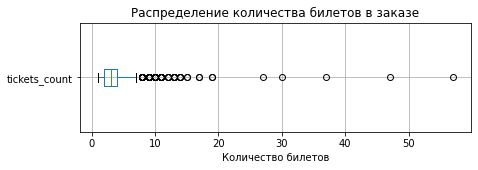

In [23]:
# Зададим размер
plt.figure(figsize=(7, 2))

# Посттроим диаграмму размаха значений
tickets_df.boxplot(column='tickets_count', vert=False)

# Добавим заголовок и метки оси
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')

# Выведем график
plt.show()

Предположение оказалось верным, на диаграмме размаха видно, что все большие значения являются выбросами. Отбросим значения, лежащие выше 99-го процентиля и посмотрим, как изменится распределение.

In [24]:
# Оставим значения меньше или равные 99-го процентилю
cleaned_tickets = tickets_df[tickets_df['tickets_count'] <= tickets_df['tickets_count'].quantile(0.99)]['tickets_count']

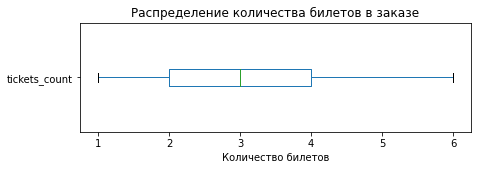

In [25]:
# Зададим размер
plt.figure(figsize=(7, 2))

# Посттроим диаграмму размаха значений
cleaned_tickets.plot.box(vert=False)

# Добавим заголовок и метки оси
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')

# Выведем график
plt.show()

При отсечении данных, выше 99-го процентиля, распределение выглядит более логично. Аномальные значения устранены. Их появление в исходном файле может быть связано с техническими ошибками при фиксировании количества билетов при покупке.

In [26]:
# Внесем изменение в исходный датасет
tickets_df = tickets_df[tickets_df['tickets_count'] <= tickets_df['tickets_count'].quantile(0.99)]

In [27]:
# Проверим корректность распределения данных столбца tickets_count
tickets_df['tickets_count'].describe()

count    191282.000000
mean          2.758942
std           1.140184
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           6.000000
Name: tickets_count, dtype: float64

Теперь проверим распределение данных в столбце `revenue`. Для начала, приведем выручку с заказа к единой валюте (российскому рублю). Для этого создадим новый столбец `revenue_rub` и расчитаем значения с помощью данных исходного датафрейма `tenge_df`

In [28]:
# Выведем поля, необходимые для расчетов
tickets_df[['revenue', 'currency_code', 'nominal', 'curs']].head(3)

,revenue,currency_code,nominal,curs
248244,960.64,rub,100,19.7383
218711,1954.78,rub,100,19.7383
146468,1209.21,rub,100,19.7383


In [29]:
# Напишем функцию для перерасчета выручки на российский рубль
def calculate_revenue_rub(row):
    if row['currency_code']=='kzt':
        return (row['curs']/row['nominal'])*row['revenue']
    else:
        return row['revenue']
    
# Создаем новый столбец и применяем функцию к каждой строке нового столбца
tickets_df['revenue_rub'] = tickets_df.apply(calculate_revenue_rub, axis=1)

In [30]:
# Проверим верность расчета для тенге
filter_df_kz = tickets_df[tickets_df['currency_code']=='kzt']
filter_df_kz[['revenue', 'currency_code', 'nominal', 'curs', 'revenue_rub']].head(3)

,revenue,currency_code,nominal,curs,revenue_rub
224768,304.26,kzt,100,19.7383,60.055752
255017,3546.14,kzt,100,19.7383,699.947752
172529,7103.29,kzt,100,19.7383,1402.068690


In [31]:
# Проверим, что исходные суммы в рублях не изменились
filter_df_ru = tickets_df[tickets_df['currency_code']=='rub']
filter_df_ru[['revenue', 'currency_code', 'nominal', 'curs', 'revenue_rub']].head(3)

,revenue,currency_code,nominal,curs,revenue_rub
248244,960.64,rub,100,19.7383,960.64
218711,1954.78,rub,100,19.7383,1954.78
146468,1209.21,rub,100,19.7383,1209.21


Для дальнейшего анализа выручки будем использовать столбец `revenue_rub` с единой валютой

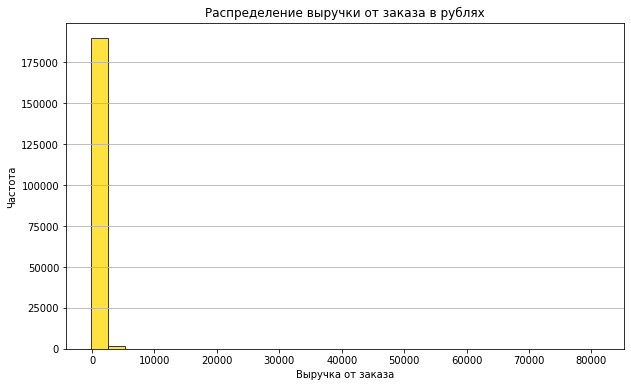

In [32]:
plt.figure(figsize=(10, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
tickets_df['revenue_rub'].plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                color='gold'
)

# Настраиваем оформление графика
plt.title('Распределение выручки от заказа в рублях')
plt.xlabel('Выручка от заказа')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show() 

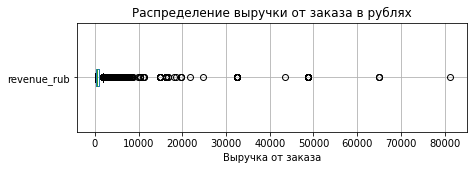

In [33]:
# Зададим размер
plt.figure(figsize=(7, 2))

# Посттроим диаграмму размаха значений
tickets_df.boxplot(column='revenue_rub', vert=False)

# Добавим заголовок и метки оси
plt.title('Распределение выручки от заказа в рублях')
plt.xlabel('Выручка от заказа')

# Выведем график
plt.show()

На диаграммах наблюдается правосимметричное распределение данных с длинным хвостом из аномально высоких значений. Отбросим все значения выше 99-го процентиля и изучим распределение данных.

In [34]:
# Оставим значения меньше или равные 99-го процентилю
cleaned_revenue = tickets_df[tickets_df['revenue_rub'] <= tickets_df['revenue_rub'].quantile(0.99)]['revenue_rub']

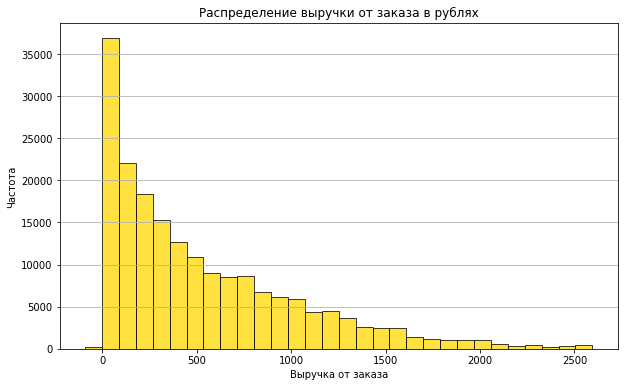

In [35]:
plt.figure(figsize=(10, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
cleaned_revenue.plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                color='gold'
)

# Настраиваем оформление графика
plt.title('Распределение выручки от заказа в рублях')
plt.xlabel('Выручка от заказа')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

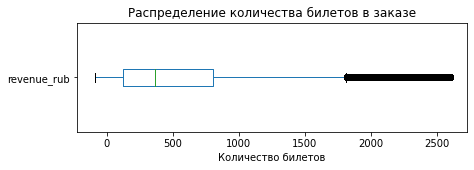

In [36]:
# Зададим размер
plt.figure(figsize=(7, 2))

# Посттроим диаграмму размаха значений
cleaned_revenue.plot.box(vert=False)

# Добавим заголовок и метки оси
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')

# Выведем график
plt.show()

Теперь распределение выручки выглядит более информативно. На диаграмме размаха все еще наблюдается небольшая часть аномально высоких значений, но они уже не так сильно влияют на общее распределение данных и гистограмму. Применим изменение с отбрасыванием выбросов ко всему датафрейму.

In [37]:
# Внесем изменение в исходный датасет
tickets_df = tickets_df[tickets_df['revenue_rub'] <= tickets_df['revenue_rub'].quantile(0.99)]

Также на диаграмме наблюдаются **отрицательные значения выручки**. Вычислим, какой объем выручки приходится на отрицательные и нулевые значения.

In [38]:
neg_values = round(100 * tickets_df[tickets_df['revenue_rub']<0]['revenue_rub'].count() / tickets_df['revenue_rub'].count(), 2)
zero_values = round(100 * tickets_df[tickets_df['revenue_rub']==0]['revenue_rub'].count() / tickets_df['revenue_rub'].count(), 2)

display(f'Всего в датасете {neg_values}% отрицательных значений и {zero_values}% нулевых значений')

'Всего в датасете 0.14% отрицательных значений и 1.66% нулевых значений'

Выведем строки с отрицательными и нулевыми значениями выручки и проверим, есть ли закономерности их появления с другими столбцами датафрейма

In [39]:
filter_df_neg = tickets_df[tickets_df['revenue_rub']<0]
display(filter_df_neg[['created_dt_msk', 'service_name', 'device_type_canonical', 'event_type_main', 'organizers', 'region_name', 'revenue_rub']])

,created_dt_msk,service_name,device_type_canonical,event_type_main,organizers,region_name,revenue_rub
224268,2024-10-31,Билеты в руки,mobile,выставки,№3907,Солнечноземская область,-4.15
289169,2024-10-31,Билеты в руки,mobile,другое,№1440,Дальнеземская область,-3.39
279136,2024-10-31,Билеты в руки,desktop,выставки,№1640,Зоринский регион,-6.33
279447,2024-10-30,Билеты без проблем,mobile,другое,№4989,Широковская область,-0.65
284579,2024-10-30,Билеты без проблем,mobile,другое,№4989,Широковская область,-1.72
...,...,...,...,...,...,...,...
251060,2024-06-03,Билеты без проблем,mobile,другое,№1771,Речицкий регион,-4.81
251052,2024-06-03,Билеты без проблем,mobile,другое,№1771,Речицкий регион,-1.60
251051,2024-06-03,Билеты без проблем,mobile,другое,№1771,Речицкий регион,-4.81
251044,2024-06-01,Билеты без проблем,mobile,другое,№1771,Речицкий регион,-1.60


In [40]:
filter_df_zero = tickets_df[tickets_df['revenue_rub']==0]
display(filter_df_zero[['created_dt_msk', 'service_name', 'device_type_canonical', 'event_type_main', 'organizers', 'region_name', 'revenue_rub']])

,created_dt_msk,service_name,device_type_canonical,event_type_main,organizers,region_name,revenue_rub
247310,2024-10-31,Лови билет!,mobile,театр,№1074,Горностепной регион,0.0
285691,2024-10-31,Лови билет!,mobile,другое,№3073,Светополянский округ,0.0
266038,2024-10-31,Билеты без проблем,desktop,другое,№1397,Каменевский регион,-0.0
223496,2024-10-31,Лучшие билеты,desktop,другое,№1973,Североярская область,0.0
290172,2024-10-31,Лови билет!,mobile,другое,№2490,Лесостепной край,0.0
...,...,...,...,...,...,...,...
159025,2024-06-01,Билеты без проблем,desktop,концерты,№4549,Каменевский регион,0.0
159115,2024-06-01,Билеты без проблем,mobile,концерты,№4549,Каменевский регион,0.0
158989,2024-06-01,Билеты без проблем,mobile,другое,№4549,Каменевский регион,0.0
285409,2024-06-01,Билеты без проблем,mobile,другое,№4253,Каменевский регион,0.0


Отрицательные и нулевые значения выручки наблюдаются на протяжении всего времени продаж, не привязаны к типу устройства или сервису-партнеру по продаже билетов. Связь с типом мероприятия или конкретным регионом отсутствует. 

Исходя из вышесказанного, можно предположить случайное появление отрицательных и нулевых значенийю Вероятной причиной их наличия в данных могут быть возвраты билетов, ошибки в ценообразовании, с учетом сервисного сбора.

Так как в совокупности такие отрицательные и нулевые данные составляют менее 2% от всех данных, отфильтруем их для дальнейшего анализа.

In [41]:
tickets_df = tickets_df[tickets_df['revenue_rub']>0]

In [42]:
# Убедимся в корректности распределения данных
tickets_df['revenue_rub'].describe()

count    186072.000000
mean        540.988639
std         506.671862
min           0.020000
25%         137.160000
50%         381.980000
75%         810.300000
max        2594.440000
Name: revenue_rub, dtype: float64

### 2.5 Добавление дополнительных полей

Мы уже добавили в исходный датафрейм новое поле `revenue_rub` для приведения валюты к единому виду. Теперь добавим еще несколько полей для удобства исследовательского анализа.

Добавим поле `one_ticket_revenue_rub`, в котором будет храниться информация о размере выручки с продажи одного билета на мероприятие

In [43]:
# Добавляем поле, разделив суммарную выручку за заказ на количество билетов в нем
tickets_df['one_ticket_revenue_rub'] = tickets_df['revenue_rub']/tickets_df['tickets_count']

In [44]:
# Для проверки выводим значимые поля
tickets_df[['revenue_rub', 'tickets_count', 'one_ticket_revenue_rub']].head(3)

,revenue_rub,tickets_count,one_ticket_revenue_rub
248244,960.64,3,320.213333
218711,1954.78,5,390.956000
146468,1209.21,4,302.302500


Теперь добавим новые поля `month` и `season` для анализа сезонных изменений в продажах. В поле `month` будет храниться информация о месяце оформления заказа, а в поле `season` - информация о соответствующем покупке сезоне (лето, осень, зима или весна)

In [45]:
# Выделим месяц из даты соверщения заказа
tickets_df['month'] = tickets_df['created_dt_msk'].dt.month

In [46]:
# Понизим разряд бит нового столбца
tickets_df['month'] = pd.to_numeric(tickets_df['month'], downcast='integer')

In [47]:
# Напишем функцию для заполнения столбца по сезонам

def season_definition(row):
    if row['month'] in [3, 4, 5]:
        return 'весна'
    elif row['month'] in [6, 7, 8]:
        return 'лето'
    elif row['month'] in [9, 10, 11]:
        return 'осень'
    else:
        return 'зима'
    
# Создаем новый столбец и применяем функцию к каждой строке нового столбца
tickets_df['season'] = tickets_df.apply(season_definition, axis=1)

In [48]:
# Для проверки выводим значимые поля c конца
tickets_df[['created_dt_msk', 'month', 'season']].tail(3)

,created_dt_msk,month,season
197313,2024-06-01,6,лето
29379,2024-06-01,6,лето
290451,2024-06-01,6,лето


Обратим внимание на один момент, в исходном описании было заявлено, что данные предоставлены за период с 1 июня по 31 октября 2024 года. Соответственно, в столбце `month` должно быть только 5 значений, а в столбце `season` - только два. Проверим, что всё корректно.

In [49]:
display(tickets_df['month'].unique())
display(tickets_df['season'].unique())

array([10,  9,  8,  7,  6], dtype=int8)

array(['осень', 'лето'], dtype=object)

In [50]:
# выведем информацию об итоговом датафрейме по завершению обработки
tickets_df.info()

# Количество строк итогового датафрейма
lens_of_new = len(tickets_df)
display(f'Количество строк датафрейма после обработки: {lens_of_new}')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 186072 entries, 248244 to 290451
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                186072 non-null  int32         
 1   user_id                 186072 non-null  object        
 2   created_dt_msk          186072 non-null  datetime64[ns]
 3   created_ts_msk          186072 non-null  datetime64[ns]
 4   event_id                186072 non-null  int32         
 5   cinema_circuit          186072 non-null  object        
 6   age_limit               186072 non-null  int8          
 7   currency_code           186072 non-null  object        
 8   device_type_canonical   186072 non-null  object        
 9   revenue                 186072 non-null  float64       
 10  service_name            186072 non-null  object        
 11  tickets_count           186072 non-null  int8          
 12  total                   1

'Количество строк датафрейма после обработки: 186072'

### 2.6 Промежуточный вывод

#### **В результате предобработки данных:**
- **Пропуски** в столбце `days_since_prev` были заменены на **индикатор -1**;
- Столбцы `created_dt_msk` и `created_ts_msk` были приведены к типу данных **datetime64**;
- У целочисленных столбцов была проведена **оптимизация с понижением разряда быт**;
- В ходе проверки неявных дубликатов в датасете было выявлено **144699 строк с дублирующимися** `user_id`, `event_id` и `created_dt_msk`, отличных по времени совершения транзакции и выручки с заказа. Было предположено, что в результате изменения заказа пользователями, могли происходить технические сбои, присваивающие незавершонной транзакции новый `order_id`. **Все дублирующиеся записи, кроме самой поздней были удалены**;
- Столбцы `tickets_count` и `revenue_rub` были проверены на **наличие аномальных значений** через визуализации распределения данных. **Выявленные выбросы были отброшены с помощью отсечения данных, превышающих 99-ый процентиль** и удаления отрицательных и нулевых значений выручки;
- К исходному датафрейму были **добавлены новые поля** `revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`:
1. `revenue_rub`- выручка с заказа, пересчитанная в российские рубли 
2. `one_ticket_revenue_rub` - выручка с продажи одного билета 
3. `month` - месяц оформления заказа
4. `season` - сезон оформления заказа (лето, весна, осень, зима)

In [51]:
count_of_deleted_str = lens_of_start - lens_of_new
shere_of_deleted_str = (lens_of_start - lens_of_new)/lens_of_start

display(f'Количество удаленных строк в процессе предобработки данных: {count_of_deleted_str}')
display(f'Доля удаленных строк в процессе предобработки данных: {round(shere_of_deleted_str, 4)}')

'Количество удаленных строк в процессе предобработки данных: 104539'

'Доля удаленных строк в процессе предобработки данных: 0.3597'

Датасет после обработки данных содержит **186072** строки и **32** столбца, в объеме **38.9+ MB** В ходе предобработки было удалено всего **104539 строк** датафрейма из 290611, что составляет **36.0%**

<a id="исследовательский-анализ"></a>
## 3. Исследовательский анализ данных

<a id="анализ-распределения"></a>
### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

Анализ дашборда показал, что в данных наблюдается сезонность — осенью количество заказов увеличивается. Изучим изменение пользовательской активности в разрезе сезонности

#### 3.1.1 Распределение количества заказов по месяцам

Для начала, изучим, как меняется количество заказов по месяцам

In [52]:
# Выведем информацию распределении количества заказов по месяцам
display('Количество заказов в разрезе месяца')
display(tickets_df.groupby('month')['order_id'].count().sort_values(ascending=True))

'Количество заказов в разрезе месяца'

month
6     23062
7     26466
8     29921
9     44765
10    61858
Name: order_id, dtype: int64

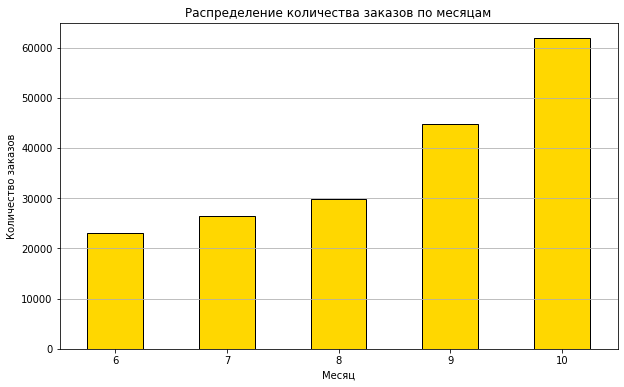

In [53]:
# Задаём размер графика
plt.figure(figsize=(10, 6))

tickets_df['month'].value_counts().sort_values(ascending=True).plot(
                   kind='bar',
                   rot=0,
                   legend=False,
                   color='gold',
                   edgecolor='black',
                   title='Распределение количества заказов по месяцам')
        
# Настраиваем оформление графика
plt.xlabel('Мeсяц')
plt.ylabel('Количество заказов')
# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

Из распределения количества заказов по месяцам **наблюдается явный рост числа заказов от июня к октябрю 2024 года**.

#### 3.1.2 Распределение заказов между сезонами в разрезе типа мероприятия

Сравним как распределяются заказы между сезонами в разрезе типа мероприятия. Так как количество заказов в разные сезоны может несоизмеримо изменяться, сравнивать будем относительные (долевые) показатели

In [54]:
# Находим количество заказов летом по каждому типу мероприятия и их долю
summer_counts = tickets_df[tickets_df['season'] == 'лето'].groupby('event_type_main')['order_id'].nunique()
summer_shares = summer_counts/summer_counts.sum()

# Находим количество заказов осенью по каждому типу мероприятия и их долю
autumn_counts = tickets_df[tickets_df['season'] == 'осень'].groupby('event_type_main')['order_id'].nunique()
autumn_shares = autumn_counts/autumn_counts.sum()

# Выведем отдельный датафрейм
season_event_type_values = pd.DataFrame({'тип мероприятия': summer_counts.index, 
                                         'кол-во заказов летом': summer_counts.values, 
                                         'доля заказов летом': summer_shares.values,
                                         'кол-во заказов осенью': autumn_counts.values, 
                                         'доля заказов осенью': autumn_shares.values})

display('Распределение количества заказов в сезон по типу мероприятия')
display(season_event_type_values)

'Распределение количества заказов в сезон по типу мероприятия'

,тип мероприятия,кол-во заказов летом,доля заказов летом,кол-во заказов осенью,доля заказов осенью
0,выставки,1803,0.022694,1713,0.016066
1,другое,20128,0.253345,22241,0.208595
2,концерты,35172,0.442699,42101,0.394859
3,спорт,1564,0.019686,7294,0.068409
4,стендап,4696,0.059107,4917,0.046116
5,театр,15892,0.200028,27237,0.255451
6,ёлки,194,0.002442,1120,0.010504


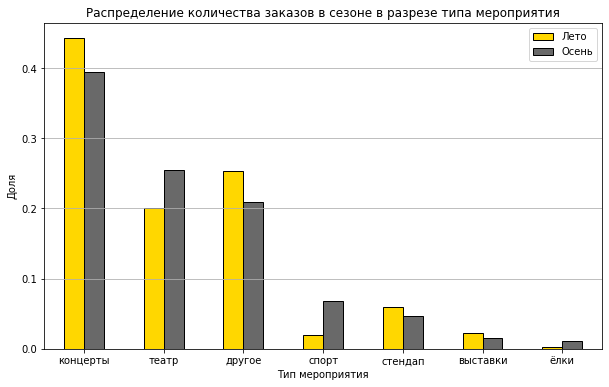

In [55]:
# Устанавливаем индекс для корректных подписей по оси X
plot_df = season_event_type_values.set_index('тип мероприятия')[['доля заказов летом', 'доля заказов осенью']].sort_values('доля заказов осенью', ascending=False)

# Переименуем столбцы для легенды
plot_df.columns = ['Лето', 'Осень']

# Строим график
plot_df.plot(kind='bar', figsize=(10, 6), legend=True, color=['gold', 'dimgray'], edgecolor='black')
plt.title('Распределение количества заказов в сезоне в разрезе типа мероприятия')
plt.ylabel('Доля')
plt.xlabel('Тип мероприятия')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

По типу мероприятия летом и осенью наблюдается схожее распределение заказов: лидирующие позиции распределены между концертами, театром и категорией "другое", а наименее популярное - занимают ёлки. Однако можно заметить, что **в осенний период категории театр, спорт и ёлки более популярны, чем летом**. Такая активность может объясняться тем, что старт театрального и спортивного сезонов чаще всего приходится на осенний период, а ёлки становятся интересны для планирования новогодних праздников ближе к зиме.

#### 3.1.3 Распределение заказов между сезонами в разрезе типа устройства

In [56]:
# Находим количество заказов летом по каждому типу устройства и их долю
summer_counts_2 = tickets_df[tickets_df['season'] == 'лето'].groupby('device_type_canonical')['order_id'].nunique()
summer_shares_2 = summer_counts_2/summer_counts_2.sum()

# Находим количество заказов осенью по каждому типу устройства и их долю
autumn_counts_2 = tickets_df[tickets_df['season'] == 'осень'].groupby('device_type_canonical')['order_id'].nunique()
autumn_shares_2 = autumn_counts_2/autumn_counts_2.sum()

# Выведем отдельный датафрейм
season_device_values = pd.DataFrame({'тип устройства': summer_counts_2.index, 
                                     'кол-во заказов летом': summer_counts_2.values, 
                                     'доля заказов летом': summer_shares_2.values,
                                     'кол-во заказов осенью': autumn_counts_2.values, 
                                     'доля заказов осенью': autumn_shares_2.values})

display('Распределение количества заказов в сезон по типу устройства')
display(season_device_values)

'Распределение количества заказов в сезон по типу устройства'

,тип устройства,кол-во заказов летом,доля заказов летом,кол-во заказов осенью,доля заказов осенью
0,desktop,14766,0.185855,19693,0.184697
1,mobile,64683,0.814145,86930,0.815303


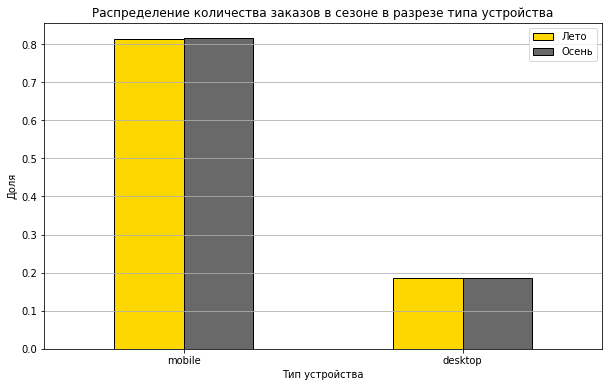

In [57]:
# Устанавливаем индекс для корректных подписей по оси X
plot_df_2 = season_device_values.set_index('тип устройства')[['доля заказов летом', 'доля заказов осенью']].sort_values('доля заказов осенью', ascending=False)

# Переименуем столбцы для легенды
plot_df_2.columns = ['Лето', 'Осень']

# Строим график
plot_df_2.plot(kind='bar', figsize=(10, 6), legend=True, color=['gold', 'dimgray'], edgecolor='black')
plt.title('Распределение количества заказов в сезоне в разрезе типа устройства')
plt.ylabel('Доля')
plt.xlabel('Тип устройства')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

Распределение по **типу устройств имеет одинаковый вид и для летнего, и для осеннего сезонов**. Большинство пользователей предпочитает делать заказы с мобильных устройств. 

#### 3.1.4 Распределение заказов между сезонами в разрезе возрастного рейтинга

In [58]:
# Находим количество заказов летом по возрастному рейтингу и их долю
summer_counts_3 = tickets_df[tickets_df['season'] == 'лето'].groupby('age_limit')['order_id'].nunique()
summer_shares_3 = summer_counts_3/summer_counts_3.sum()

# Находим количество заказов осенью по возрастному рейтингу и их долю
autumn_counts_3 = tickets_df[tickets_df['season'] == 'осень'].groupby('age_limit')['order_id'].nunique()
autumn_shares_3 = autumn_counts_3/autumn_counts_3.sum()

# Выведем отдельный датафрейм
season_age_values = pd.DataFrame({'возрастной рейтинг': summer_counts_3.index, 
                                  'кол-во заказов летом': summer_counts_3.values, 
                                  'доля заказов летом': summer_shares_3.values,
                                  'кол-во заказов осенью': autumn_counts_3.values, 
                                  'доля заказов осенью': autumn_shares_3.values})

display('Распределение количества заказов в сезон по возрастному рейтингу')
display(season_age_values)

'Распределение количества заказов в сезон по возрастному рейтингу'

,возрастной рейтинг,кол-во заказов летом,доля заказов летом,кол-во заказов осенью,доля заказов осенью
0,0,14142,0.178001,21147,0.198334
1,6,14539,0.182998,20213,0.189574
2,12,16274,0.204836,24211,0.227071
3,16,22869,0.287845,28645,0.268657
4,18,11625,0.146320,12407,0.116363


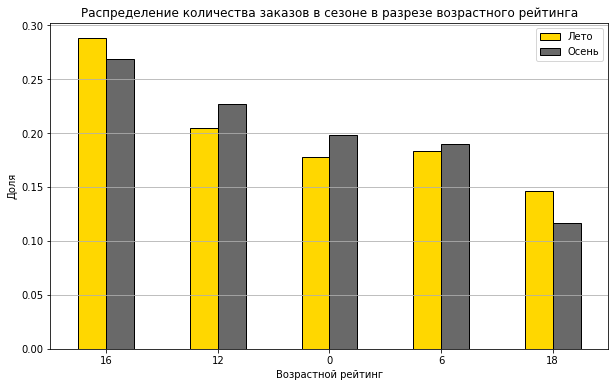

In [59]:
# Устанавливаем индекс для корректных подписей по оси X
plot_df_3 = season_age_values.set_index('возрастной рейтинг')[['доля заказов летом', 'доля заказов осенью']].sort_values('доля заказов осенью', ascending=False)

# Переименуем столбцы для легенды
plot_df_3.columns = ['Лето', 'Осень']

# Строим график
plot_df_3.plot(kind='bar', figsize=(10, 6), legend=True, color=['gold', 'dimgray'], edgecolor='black')
plt.title('Распределение количества заказов в сезоне в разрезе возрастного рейтинга')
plt.ylabel('Доля')
plt.xlabel('Возрастной рейтинг')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

**Осенью** наблюдается **рост спроса на "детские" категории билетов с возрастным рейтингом 0, 6, 12** по сравнению с летом. Это может быть связано с групповыми мероприятиями в школах по посейщению театров, кино и пр. А **летом вырастает спрос на подростково-молодежные категории с возрастным роейтингом 16, 18**, что возможно связано с каникулами в школах, колледжах и университетах и ростом потребности в развлекательном времяпровождении. 

#### 3.1.5 Изменение выручки с продажи одного билета в разрезе типа мероприятия летом и осенью

In [60]:
# Расчитаем среднее значение выручки с одного билета для летнего и осеннего сезонов
summer_avg_one_tick_rev = tickets_df[tickets_df['season'] == 'лето'].groupby('event_type_main')['one_ticket_revenue_rub'].mean()
autumn_avg_one_tick_rev = tickets_df[tickets_df['season'] == 'осень'].groupby('event_type_main')['one_ticket_revenue_rub'].mean()

# Вычислим относительное изменение осенних значений по сравнению с летними, abs - модуль, опускающий знак разницы
relative_diff = abs(summer_avg_one_tick_rev-autumn_avg_one_tick_rev)/summer_avg_one_tick_rev


# Выведем отдельный датафрейм
season_avg_one_tick_rev = pd.DataFrame({'тип мероприятия': summer_avg_one_tick_rev.index, 
                                        'ср.выручка за билет летом': summer_avg_one_tick_rev.values, 
                                        'ср.выручка за билет осенью': autumn_avg_one_tick_rev.values,
                                        'относительная разница': relative_diff.values})

display('Изменение выручки с продажи одного билета в сезон по типу мероприятия в руб')
display(season_avg_one_tick_rev)

'Изменение выручки с продажи одного билета в сезон по типу мероприятия в руб'

,тип мероприятия,ср.выручка за билет летом,ср.выручка за билет осенью,относительная разница
0,выставки,87.322884,92.194984,0.055794
1,другое,88.013242,80.017604,0.090846
2,концерты,295.446377,273.529818,0.074181
3,спорт,64.722088,59.000568,0.088401
4,стендап,214.420735,231.437936,0.079364
5,театр,213.193775,176.438257,0.172404
6,ёлки,277.689919,233.590021,0.158810


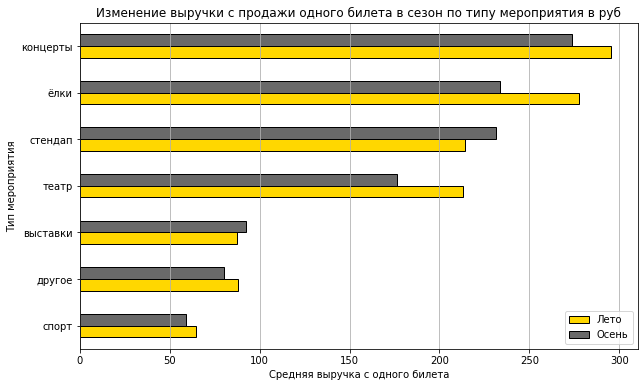

In [61]:
# Устанавливаем индекс для корректных подписей по оси X
plot_df_4 = season_avg_one_tick_rev.set_index('тип мероприятия')[['ср.выручка за билет летом', 'ср.выручка за билет осенью']].sort_values('ср.выручка за билет осенью', ascending=True)

# Переименуем столбцы для легенды
plot_df_4.columns = ['Лето', 'Осень']

# Строим график
plot_df_4.plot(kind='barh', figsize=(10, 6), legend=True, color=['gold', 'dimgray'], edgecolor='black')
plt.title('Изменение выручки с продажи одного билета в сезон по типу мероприятия в руб')
plt.xlabel('Средняя выручка с одного билета')
plt.ylabel('Тип мероприятия')
plt.xticks(rotation=0)
plt.grid(axis='x')
plt.show()

В **осенний** период средняя выручка с одного билета **выше** у категорий **стандап (+0,08), выставки (+0.05) и спорт (+0.01)** по сравнению с летним периодом. При этом **осенью понижаются** значения средней выручки с одного билета относительно лета в категориях: **театр (-0.17), ёлки (-0.16), концерты (-0.07) и другое (-0.1)**

Визуально сравним относительную разницу между осенними и летними значениями средней выручки с одного билета

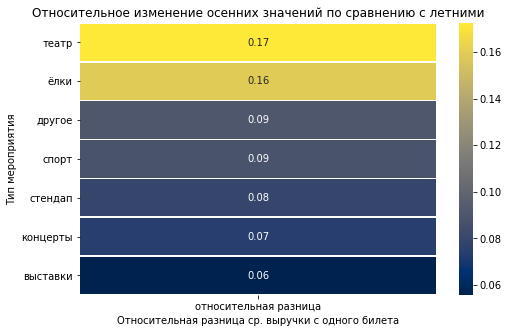

In [62]:
plt.figure(figsize=(8, 5))

relative_diff_df = season_avg_one_tick_rev.set_index('тип мероприятия')[['относительная разница']].sort_values(by='относительная разница', ascending=False)
sns.heatmap(data=relative_diff_df, annot=True, fmt='.2f', linewidths=0.5, cmap='cividis')

plt.title('Относительное изменение осенних значений по сравнению с летними')
plt.ylabel('Тип мероприятия')
plt.xlabel('Относительная разница ср. выручки с одного билета')
plt.show()

Из тепловой карты видно, что **самые большие изменения в средней стоимости одного билета** происходят в категорях **театр и ёлки** с **понижением значения к осени**. Такая тенденция может быть связана с рекламными мероприятиями для привлечения большего числа зрителей в начале сезона продаж билетов

<a id="осенняя-активность"></a>
### 3.2. Осенняя активность пользователей

Подробнее изучим активность пользователей в осенний сезон

In [63]:
# Отфильтруем исходный датасет по сезону, оставим только осенний период
autumn_df = tickets_df[tickets_df['season']=='осень']

#### 3.2.1 Динамика изменения активности по дням

Изучим динамику изменения показателей по дням. В качестве метрики, выберем число заказов, количество активных пользователей, среднее число заказов на пользователя и среднюю стоимость одного билета

In [64]:
# Вычислим количество заказов, активных пользователей и среднее число заказов на пользователя за день
orders_count = autumn_df.groupby('created_dt_msk')['order_id'].count()
users_count = autumn_df.groupby('created_dt_msk')['user_id'].nunique()
orders_per_user = round(orders_count/users_count, 2)
one_tick_rev = round(autumn_df.groupby('created_dt_msk')['one_ticket_revenue_rub'].mean(), 2)

# Выведем первые 5 значений
autumn_tab = pd.DataFrame({'дата': orders_count.index, 
                            'кол-во заказов': orders_count.values, 
                            'кол-во активных пользователей': users_count.values,
                            'ср.число заказов на пользователя': orders_per_user.values,
                            'ср.стоимость билета' : one_tick_rev.values})

display('Осенняя активность по дням')
display(autumn_tab.head())

'Осенняя активность по дням'

,дата,кол-во заказов,кол-во активных пользователей,ср.число заказов на пользователя,ср.стоимость билета
0,2024-09-01,888,555,1.60,202.98
1,2024-09-02,976,570,1.71,190.79
2,2024-09-03,1525,776,1.97,141.02
3,2024-09-04,1162,683,1.70,181.75
4,2024-09-05,1353,739,1.83,191.54


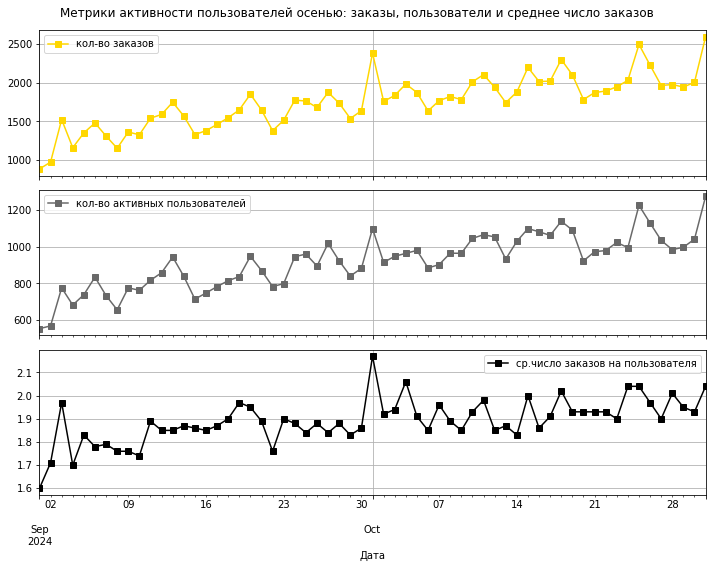

In [65]:
# Устанавливаем индекс для корректных подписей по оси X
plot_day = autumn_tab.set_index('дата')[['кол-во заказов', 'кол-во активных пользователей', 'ср.число заказов на пользователя']]

# Строим график
plot_day.plot(kind='line', 
              figsize=(10, 8), 
              legend=True, 
              color=['gold', 'dimgray', 'black'], 
              subplots=True, 
              sharex=True, 
              sharey=False,
              grid = True,
              marker = 's',
              title = 'Метрики активности пользователей осенью: заказы, пользователи и среднее число заказов')

plt.tight_layout()
plt.xlabel('Дата')
plt.show()

В осенний период наблюдается **постепенный рост количества заказов и активных пользователей с небольшими колебаниями по дням**. Наиболее высокие значения достигаются в первые дни месяца. Возможно, это связано с обновлением афиши в начале каждого месяца и, соответственно, повышенным интересом пользователей, ожидающих информацию о премьерах. Аналогичным образом меняется среднее число заказов на пользователя

**Отдельно рассмотрим изменение средней стоимости одного билета по дням**

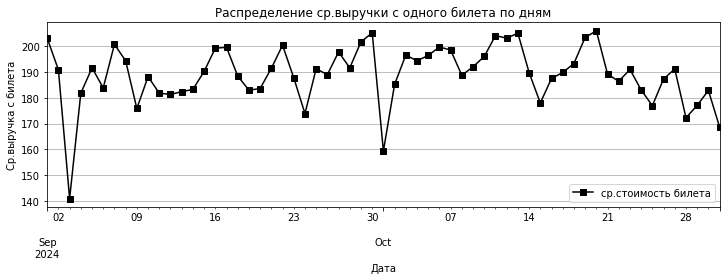

In [66]:
# Устанавливаем индекс для корректных подписей по оси X
plot_day_1 = autumn_tab.set_index('дата')[['ср.стоимость билета']]

# Строим график
plot_day_1.plot(kind='line', 
              figsize=(10, 4), 
              legend=True, 
              color='black', 
              marker = 's',
              title = 'Распределение ср.выручки с одного билета по дням')

plt.tight_layout()
plt.grid(axis='y')
plt.xlabel('Дата')
plt.ylabel('Ср.выручка с билета')
plt.show()

Средняя выручка с билета **колеблется в небольших диапозонах от 170 до 200 рублей**, достигая **наиболее низких значений (140-160 рублей) в пик пользовательской активности (в первые дни месяца)**

#### 3.2.2 Динамика изменения активности за неделю

Теперь рассмотрим динамику изменения активности по дням недели

In [67]:
# Добавим новый столбец week, где будут храниться дни недели соответствующей дате; +1 добавим, чтобы ПН был первым днем
autumn_df['week'] = autumn_df['created_dt_msk'].dt.day_of_week+1

# Выведем несколько строк для проверки
autumn_df[['order_id', 'user_id', 'one_ticket_revenue_rub', 'created_dt_msk', 'week']].head(3)

/tmp/ipykernel_48/2487537879.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  autumn_df['week'] = autumn_df['created_dt_msk'].dt.day_of_week+1


,order_id,user_id,one_ticket_revenue_rub,created_dt_msk,week
248244,1696414,443fe1aafcc96ab,320.213333,2024-10-31,4
218711,7928369,7eb4fc207ecc10f,390.956000,2024-10-31,4
146468,5935170,992f64b9657ff00,302.302500,2024-10-31,4


In [68]:
# Вычислим количество заказов, активных пользователей и среднее число заказов на пользователя за день
orders_count = autumn_df.groupby('week')['order_id'].count()
users_count = autumn_df.groupby('week')['user_id'].nunique()
orders_per_user = round(orders_count/users_count, 2)
one_tick_rev = round(autumn_df.groupby('week')['one_ticket_revenue_rub'].mean(), 2)

# Выведем первые 5 значений
autumn_tab_1 = pd.DataFrame({'день недели' : orders_count.index, 
                            'кол-во заказов': orders_count.values, 
                            'кол-во активных пользователей': users_count.values,
                            'ср.число заказов на пользователя': orders_per_user.values,
                            'ср.стоимость билета' : one_tick_rev.values})

display('Осенняя активность по неделям')
display('ПН-1, ВС-7')
display(autumn_tab_1)

'Осенняя активность по неделям'

'ПН-1, ВС-7'

,день недели,кол-во заказов,кол-во активных пользователей,ср.число заказов на пользователя,ср.стоимость билета
0,1,14370,4431,3.24,189.51
1,2,16323,4785,3.41,176.16
2,3,15520,4808,3.23,187.07
3,4,16759,4962,3.38,185.74
4,5,15830,4839,3.27,189.52
5,6,14404,4524,3.18,194.67
6,7,13417,4343,3.09,199.00


'ПН-1, ВС-7'

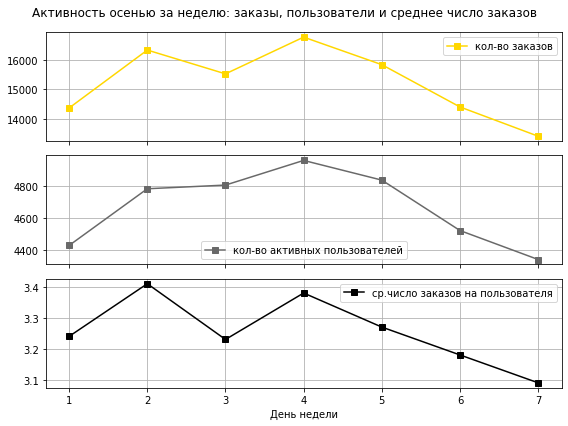

In [69]:
# Устанавливаем индекс для корректных подписей по оси X
plot_week = autumn_tab_1.set_index('день недели')[['кол-во заказов', 'кол-во активных пользователей', 'ср.число заказов на пользователя']]

display('ПН-1, ВС-7')
# Строим график
plot_week.plot(kind='line', 
              figsize=(8, 6), 
              legend=True, 
              color=['gold', 'dimgray', 'black'], 
              subplots=True, 
              sharex=True, 
              sharey=False,
              grid = True,
              marker = 's',
              title = 'Активность осенью за неделю: заказы, пользователи и среднее число заказов')

plt.tight_layout()
plt.xlabel('День недели')
plt.show()

По дням недели наблюдается **спад пользовательской активности в выходные дни по сравнению с будними**. Наивысшие показатели по количеству заказов, активных пользователей и среднего числа заказов на пользователя достигаются со вторника по четверг.

**Отдельно рассмотрим изменение средней стоимости одного билета за неделю**

'ПН-1, ВС-7'

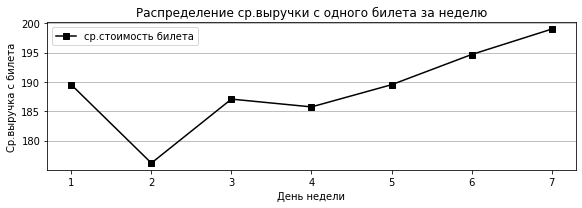

In [70]:
# Устанавливаем индекс для корректных подписей по оси X
plot_week_1 = autumn_tab_1.set_index('день недели')[['ср.стоимость билета']]

display('ПН-1, ВС-7')
# Строим график
plot_week_1.plot(kind='line', 
              figsize=(8, 3), 
              legend=True, 
              color='black', 
              marker = 's',
              title = 'Распределение ср.выручки с одного билета за неделю')

plt.tight_layout()
plt.grid(axis='y')
plt.xlabel('День недели')
plt.ylabel('Ср.выручка с билета')
plt.show()

**Наибольшие показатели средней выручки с билета приходятся на период пониженной пользовательской активности**, то есть, с пятницы по понедельник. И в целом, средняя выручка с билета достигает максимальных значений к выходным (190-195 рублей)

<a id="популярные"></a>
### 3.3. Популярные события и партнёры

Продолжим изучение осеннего периода продаж билетов

#### 3.3.1 Популярные регионы для проведения мероприятий

Расчитаем абсолютные и относительные показатели осеннего сезона в разрезе регионов проведения мероприятий. В качестве метрики, сравним уникальное количество мероприятий и общее число заказов для регионов. Выделим ТОП-10 регионов с наилучшими показателями

In [71]:
# Находим количество уникальных событий осенью по регионам и их долю
events_by_region = tickets_df[tickets_df['season'] == 'осень'].groupby('region_name')['event_id'].nunique().sort_values(ascending=False)
events_by_region_rel = events_by_region/events_by_region.sum()

# # Находим количество заказов осенью по регионам и их долю
orders_by_region = tickets_df[tickets_df['season'] == 'осень'].groupby('region_name')['order_id'].count().sort_values(ascending=False)
orders_by_region_rel = orders_by_region/orders_by_region.sum()

# Сводный датафрейм
regions_tab = pd.DataFrame({'регион': events_by_region.index, 
                            'кол-во уник-х событий': events_by_region.values, 
                            'доля уник-х событий': events_by_region_rel.values,
                            'кол-во заказов': orders_by_region.values, 
                            'доля заказов': orders_by_region_rel.values})

display('ТОП-10 популярных регионов в осенний период')
display(regions_tab.head(10))

'ТОП-10 популярных регионов в осенний период'

,регион,кол-во уник-х событий,доля уник-х событий,кол-во заказов,доля заказов
0,Каменевский регион,3889,0.246733,30743,0.288334
1,Североярская область,2594,0.164573,14424,0.135280
2,Широковская область,794,0.050374,5822,0.054604
3,Светополянский округ,755,0.047900,4963,0.046547
4,Речиновская область,529,0.033562,3248,0.030462
5,Серебринская область,456,0.028930,3111,0.029178
6,Яблоневская область,431,0.027344,3083,0.028915
7,Тепляковская область,419,0.026583,2937,0.027546
8,Горицветская область,406,0.025758,2736,0.025661
9,Солнечноземская область,401,0.025441,2396,0.022472


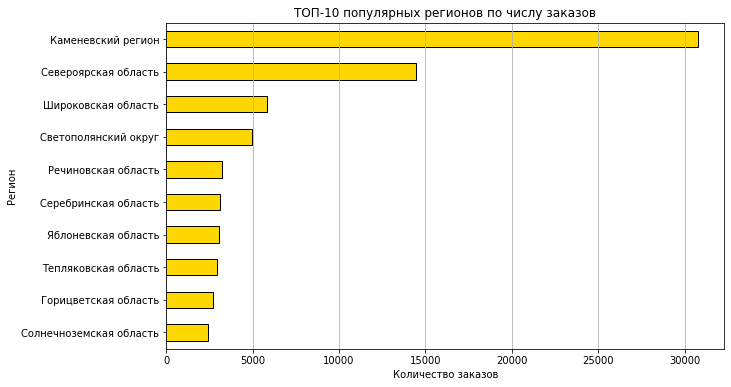

In [72]:
# Устанавливаем индекс для корректных подписей по оси X
region_df = regions_tab.set_index('регион')[['кол-во заказов']].sort_values(by='кол-во заказов', ascending = True).tail(10)

# Строим график
region_df.plot(kind='barh', figsize=(10, 6), color=['gold'], edgecolor='black', legend=False)
plt.title('ТОП-10 популярных регионов по числу заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Регион')

plt.grid(axis='x')
plt.show()

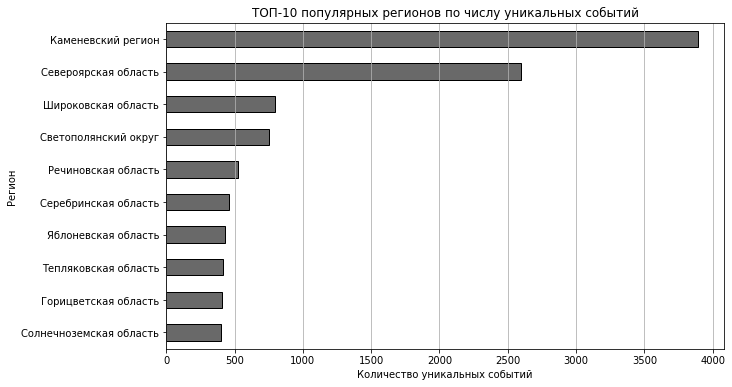

In [73]:
# Устанавливаем индекс для корректных подписей по оси X
region_df = regions_tab.set_index('регион')[['кол-во уник-х событий']].sort_values(by='кол-во уник-х событий', ascending = True).tail(10)

# Строим график
region_df.plot(kind='barh', figsize=(10, 6), color=['dimgrey'], edgecolor='black', legend=False)
plt.title('ТОП-10 популярных регионов по числу уникальных событий')
plt.xlabel('Количество уникальных событий')
plt.ylabel('Регион')

plt.grid(axis='x')
plt.show()

Из рассчитанных показателей, можно в выделить **Каменевский регион и Североярскую область как регионы с наибольшим разнообразием мероприятий, составляющих 25% и 16%**, соответственно, относительно остальных регионов по числу уникальных мероприятий. Распределение мероприятий между остальными регионами составляет не более 5% для каждого региона.

#### 3.3.1 Популярные партнёры-сервисы по продаже билетов

Расчитаем абсолютные и относительные показатели осеннего сезона в разрезе сервис-партнеров продаже билетов. В качестве метрики, сравним общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов по сервисам. Выделим ТОП-10 партнеров с наилучшими показателями

In [74]:
# Находим количество уникальных событий осенью по сервисам и их долю
events_by_service = tickets_df[tickets_df['season'] == 'осень'].groupby('service_name')['event_id'].nunique().sort_values(ascending=False)
events_by_service_rel = events_by_service/events_by_service.sum()

# Находим количество заказов осенью по сервисам и их долю
orders_by_service = tickets_df[tickets_df['season'] == 'осень'].groupby('service_name')['order_id'].count().sort_values(ascending=False)
orders_by_service_rel = orders_by_service/orders_by_service.sum()

# Находим суммарную выручку в рублях осенью по сервисам и их долю
revenue_by_service = tickets_df[tickets_df['season'] == 'осень'].groupby('service_name')['revenue_rub'].sum().sort_values(ascending=False)
revenue_by_service_rel = revenue_by_service/revenue_by_service.sum()

# Сводный датафрейм
services_tab = pd.DataFrame({'партнёр': events_by_service.index, 
                            'число уник-х событий': events_by_service.values, 
                            'доля уник-х событий': events_by_service_rel.values,
                            'кол-во заказов': orders_by_service.values, 
                            'доля заказов': orders_by_service_rel.values,
                            'сумм-я выручка': revenue_by_service.values,
                            'доля выручки': revenue_by_service_rel.values})

display('ТОП-10 популярных партнеров в осенний период')
display(services_tab.head(10))

'ТОП-10 популярных партнеров в осенний период'

,партнёр,число уник-х событий,доля уник-х событий,кол-во заказов,доля заказов,сумм-я выручка,доля выручки
0,Лови билет!,3581,0.209232,21790,0.204365,8.849691e+06,0.160743
1,Билеты без проблем,2817,0.164592,16444,0.154226,7.432388e+06,0.134999
2,Билеты в руки,2434,0.142214,12474,0.116992,7.287536e+06,0.132368
3,Облачко,1408,0.082267,12355,0.115876,6.616309e+06,0.120176
4,Лучшие билеты,1377,0.080456,10957,0.102764,6.517766e+06,0.118387
5,Мой билет,1002,0.058545,7867,0.073783,4.635734e+06,0.084202
6,Тебе билет!,857,0.050073,6513,0.061084,1.995162e+06,0.036239
7,Прачечная,727,0.042477,3413,0.032010,1.733728e+06,0.031491
8,Весь в билетах,598,0.034940,2507,0.023513,1.533944e+06,0.027862
9,Яблоко,536,0.031318,2176,0.020408,1.454227e+06,0.026414


Построим диаграмму для визуализации распределения суммарной выручки с заказов билетов по сервисам-партнерам и выделим ТОП-10 с наибольшей долей выручки относительно других сервисов

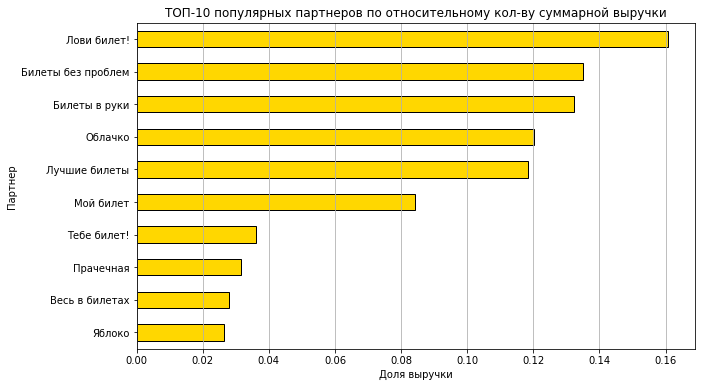

In [75]:
# Устанавливаем индекс для корректных подписей по оси X
service_df = services_tab.set_index('партнёр')[['доля выручки']].sort_values(by='доля выручки', ascending = True).tail(10)

# Строим график
service_df.plot(kind='barh', figsize=(10, 6), color=['gold'], edgecolor='black', legend=False)
plt.title('ТОП-10 популярных партнеров по относительному кол-ву суммарной выручки')
plt.xlabel('Доля выручки')
plt.ylabel('Партнер')

plt.grid(axis='x')
plt.show()

Среди сервисов-партнеров по продаже билетов выделился **явный лидер по выручке (8.85 млн руб, 16% всей выручки), числу заказов (22089 заказов, 21% всех заказов) и количеству уникальных событий (3613 событий, 21% всех событий) - это сервис "Лови билет!"**. Далее, с чуть меньшими показателями лидируют сервисы **"Билеты без проблем" и "Билеты в руки"**, чьи выручки достигают **7.4 и 7.3 млн руб.**, соответственно. В целом, **основная часть выручки и заказов распределена между первыми семью позициями ТОП-списка: их доля от всей выручки суммарно составляет 76,5%**. Таким образом на остальные 29 сервисов приходится менее 25% выручки. 

### Промежуточный вывод

**1. Распределение заказов по сегментам и их сезонные изменения**
- Наблюдается явный **рост числа заказов от июня к октябрю** 2024 года.
- **По типу мероприятия** летом и осенью наблюдается схожее распределение заказов: **лидирующие позиции распределены между концертами, театром и категорией "другое"**, а наименее популярное - занимают ёлки. Можно заметить, что в осенний период категории театр, спорт и ёлки более популярны, чем летом.
- Большинство пользователей предпочитает делать заказы с мобильных устройств. 
- **Осенью** наблюдается **рост спроса на "детские" категории билетов с возрастным рейтингом 0, 6, 12** по сравнению с летом. 
- В **осенний** период средняя выручка с одного билета **выше** у категорий **стандап (+0,08), выставки (+0.05) и спорт (+0.01)** по сравнению с летним периодом. При этом **осенью понижаются** значения средней выручки с одного билета относительно лета в категориях: **театр (-0.17), ёлки (-0.16), концерты (-0.07) и другое (-0.1)**

**2. Осенняя активность пользователей**
- В осенний период наблюдается **постепенный рост количества заказов и активных пользователей с небольшими колебаниями по дням**. Наиболее высокие значения достигаются в первые дни месяца. При этом средняя выручка с билета достигает **наиболее низких значений (140-160 рублей) в пик пользовательской активности**
- По дням недели наблюдается **спад пользовательской активности в выходные дни по сравнению с будними**. Наивысшие показатели достигаются со вторника по четверг. При этом, наибольшие показатели средней выручки с билета приходятся на период пониженной пользовательской активности.

**3. Популярные события и партнёры**
- **Каменевский регион и Североярскую область это регионы с наибольшим разнообразием мероприятий, составляющих 25% и 16%**, соответственно, относительно остальных регионов по числу уникальных мероприятий. Распределение мероприятий между остальными регионами составляет не более 5% для каждого региона.
- **Явный лидер среди партнеров** по выручке (8.85 млн руб, 16% всей выручки), числу заказов (22089 заказов, 21% всех заказов) и количеству уникальных событий (3613 событий, 21% всех событий) - это **сервис "Лови билет!"**. В целом, **основная часть выручки и заказов распределена между первыми семью позициями ТОП-списка: их доля от всей выручки суммарно составляет 76,5%**. Таким образом на остальные 29 сервисов приходится менее 25% выручки. 

<a id="статистический"></a>
## 4. Статистический анализ данных

Основные гипотезы, предполагающие большую активность пользователей мобильных устройств по сравнению со стационарными:

- **Среднее количество заказов на одного пользователя** мобильного приложения выше по сравнению с пользователями стационарных устройств.
- **Среднее время между заказами** пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

### 4.1 Проверка первой гипотезы о количестве заказов

**Первая гипотеза**: `Среднее количество заказов на одного пользователя` мобильного приложения выше по сравнению с пользователями стационарных устройств

#### 4.1.1 Оценка распределения пользователей по группам

In [76]:
# Находим количество уникальных пользователей в группe mobile
group_mobile = tickets_df[tickets_df['device_type_canonical'] == 'mobile']['user_id'].nunique() 

# Находим количество уникальных пользователей в группe desktop
group_desktop = tickets_df[tickets_df['device_type_canonical'] == 'desktop']['user_id'].nunique()

display(f'Группа мобильных устройств: {group_mobile} пользователей, группа стационарных устройств: {group_desktop} пользователей')

'Группа мобильных устройств: 19509 пользователей, группа стационарных устройств: 6875 пользователей'

In [77]:
# Считаем процентную разницу в количестве пользователей в группах по формуле, где abs - это модуль, опускающий знак разницы
percentage_diff = 100 * abs(group_mobile - group_desktop) / group_mobile
display(f'Процентная разница в количестве пользователей в группах: {round(percentage_diff, 2)} %')

'Процентная разница в количестве пользователей в группах: 64.76 %'

In [78]:
# Проверяем пересечения пользователей между группами
group_mobile = tickets_df[tickets_df['device_type_canonical'] == 'mobile']['user_id']
group_desktop = tickets_df[tickets_df['device_type_canonical'] == 'desktop']['user_id']

intersection = list(set(group_mobile) & set(group_desktop))

display(f'Пользователи одновременно в группах mobile и desktop: {intersection}')

"Пользователи одновременно в группах mobile и desktop: ['6f84b96961f9f5e', '9e3c744e5b26c17', '534e6bd9c341be5', '1aa83fda64dafd7', 'a5597b4887c922d', 'd19627888d7bd15', '605252153ed7b2a', 'ebb13d848ea2207', '8860b4ff17fcc70', 'c2b0524ba08e281', 'a6c29ab806e766e', '84adc24dd93e902', '49ecf769e8b95a5', 'a1b51afb4188fa5', 'c8277c8e9ad70ef', '351046f0523bc44', 'a9f060dc93ef102', 'ad24ec4d3883a71', 'a380f2314f38ca8', 'b6a21739b078a38', '8a1f5d51b7c70cf', '441598f309fdd22', '851fc78fe0019d0', '9dc71c6fca7de95', 'f55d9fcad984451', '77a6f7754f47a7a', 'cc5bd8bc1197b50', 'b6ded7b12a4f6c6', 'a5d0f91d9f98d41', '39f45ffb7750015', '761b1deaf6927f8', '8f4e4d4a4ae404e', '16fd7c1b112bb7f', 'b4d71019c0c5915', '1be7d74433aea98', '5771bc571cf7f37', 'e438e1cfcaad77e', '5eb41a38125a807', '2334ac3fa90a68c', 'c64ef813b4341fc', 'fd8453a37ee92dc', 'c92dbe1d51e0231', '9b7deb15d72a7b1', '91ff37be62757b8', '0d3d924f9f83f86', 'f89255e1f8b77af', 'fb1314545976408', 'c7246915c5662bb', 'a1279a20b35f9c2', 'b199462cde92

В группах присутствует много пользователей, использующих как мобильную, так и стационарную версию устройств, но их поведение в разных версиях может отличаться. Поэтому оставим группы без изменений.

In [79]:
# % доля пользователей в каждой группе
100 * tickets_df[tickets_df['device_type_canonical'] == 'mobile']['user_id'].nunique() / tickets_df['user_id'].nunique(), 100 * tickets_df[tickets_df['device_type_canonical'] == 'desktop']['user_id'].nunique() / tickets_df['user_id'].nunique()

(90.06509394764785, 31.7390702183648)

#### 4.1.2 Расчитаем необходимый размер выборки для статистического теста

Найдем std для количества заказов на одного пользователя по всем данным. Затем вычислим требуемый размер выборки

In [80]:
# Количество заказов для каждого пользователя
orders_per_user = tickets_df.groupby('user_id')['order_id'].nunique()

# Считаем стандартное отклонение
orders_std = orders_per_user.std()
display(orders_std)

80.82999928584816

При таком большом стандартном отклонении, потребуется очень много данных для обнаружения минимального эффекта в 5-15%. Так как на данном этапе исследования данные по количеству пользователей ограничены, проверим, какой минимальный эффект следует ожидать. Расчитаем среднее значение и выберем в качестве минимально детектируемого эффекта прирост в 30%

In [81]:
orders_mean = orders_per_user.mean()
display(f'среднее значение: {orders_mean}')

koeff = orders_mean*0.30
display(f'детектируемая разница: {koeff}')

'среднее значение: 8.590185125340474'

'детектируемая разница: 2.577055537602142'

In [82]:
# Размер эффекта (разница в 2.577 заказа при std=80.83)
effect_size = koeff / orders_std
n = TTestIndPower().solve_power(effect_size, power=0.8, alpha=0.05)
print(f'Нужно наблюдений на группу: {int(n)} пользователя')

Нужно наблюдений на группу: 15444 пользователя


#### 4.1.3 Выбор статистического теста

Исходя из имеющихся данных, группа мобильных устройств состоит из 19509 пользователей, группа стационарных устройств - из 6875 пользователей. **Между группами наблюдается большая разница в 64.76 %**. Только группа mobile содержит достаточно данных для минимального детектируемого эффекта в 30%. Вероятно, **тест сможет выявить только более ощутимый эффект (45% и выше)**.

Дополнительно посмотрим распределение данных в каждой группе и определимся со статистическим тестом

In [83]:
# Находим значения числа заказов на пользователя в группe mobile 
mobile_df = tickets_df[tickets_df['device_type_canonical'] == 'mobile']
orders_per_user_mobile = mobile_df.groupby('user_id')['order_id'].mean()

# Находим значения числа заказов на пользователя в группe desktop
desktop_df = tickets_df[tickets_df['device_type_canonical'] == 'desktop']
orders_per_user_desktop = desktop_df.groupby('user_id')['order_id'].mean()

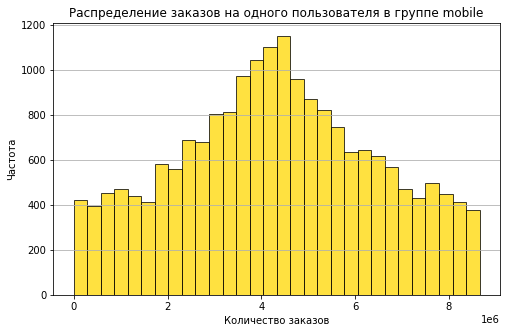

In [84]:
plt.figure(figsize=(8, 5))

# Строим гистограмму с помощью pandas через plot(kind='hist')
orders_per_user_mobile.plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                color='gold'
)

# Настраиваем оформление графика
plt.title('Распределение заказов на одного пользователя в группе mobile')
plt.xlabel('Количество заказов')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

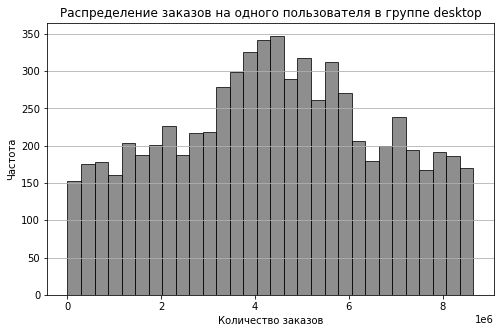

In [85]:
plt.figure(figsize=(8, 5))

# Строим гистограмму с помощью pandas через plot(kind='hist')
orders_per_user_desktop.plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                color='dimgrey'
)

# Настраиваем оформление графика
plt.title('Распределение заказов на одного пользователя в группе desktop')
plt.xlabel('Количество заказов')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

В группах наблюдается нормальное распределение среднего числа заказов на одного пользователя. Так как выборки отличны по размеру более чем на 25%, лучше всего подойдет **t-test с поправкой Уэлча**

#### 4.1.4 Проведение статистического теста

Сформулируем нулевую и альтернативную гипотезы:

- **Нулевая гипотеза:** Среднее количество заказов на одного пользователя в двух группах (mobile и desktop) не различаются
- **Альтернативная гипотеза:** Среднее количество заказов на одного пользователя в группе mobile больше, чем в группе desktop, и это статистически значимо

In [86]:
orders_per_user_mobile = mobile_df.groupby('user_id')['order_id'].mean()
orders_per_user_desktop = desktop_df.groupby('user_id')['order_id'].mean()

alpha = 0.05

# Проводим t-тест Уэлча
stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    orders_per_user_mobile, 
    orders_per_user_desktop, 
    equal_var=False,
    alternative='greater') 

if p_value_welch_ttest > alpha:
    print(f'p-value теста Уэлча = {round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение. Выборочные средние в группах mobile и desktop равны')
    print('Интерпретация: среднее число заказов на пользователя в группах не различаются')
else:
    print(f'p-value теста Уэлча = {round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения. Выборочные средние в группах mobile и desktop не равны')
    print('Интерпретация: среднее число заказов на пользователя в группе mobile больше')

p-value теста Уэлча = 0.99
Нулевая гипотеза находит подтверждение. Выборочные средние в группах mobile и desktop равны
Интерпретация: среднее число заказов на пользователя в группах не различаются


### 4.2 Проверка второй гипотезы о времени между заказами

**Вторая гипотеза**: `Среднее время между заказами` пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств

#### 4.2.1 Оценка распределения пользователей по группам

Во время предобработки данных мы заменили пропущенные значения в столбце `days_since_prev` на значения-индикаторы. Отфильтруем данные для корректного анализа

In [87]:
# Фильтруем данные
tickets_df_fil = tickets_df[tickets_df['days_since_prev']!='-1']

In [88]:
# Находим количество уникальных пользователей в группe mobile
group_mobile = tickets_df_fil[tickets_df_fil['device_type_canonical'] == 'mobile']['user_id'].nunique() 

# Находим количество уникальных пользователей в группe desktop
group_desktop = tickets_df_fil[tickets_df_fil['device_type_canonical'] == 'desktop']['user_id'].nunique()

display(f'Группа мобильных устройств: {group_mobile} пользователей, группа стационарных устройств: {group_desktop} пользователей')

'Группа мобильных устройств: 19509 пользователей, группа стационарных устройств: 6875 пользователей'

In [89]:
# Считаем процентную разницу в количестве пользователей в группах по формуле, где abs - это модуль, опускающий знак разницы
percentage_diff = 100 * abs(group_mobile - group_desktop) / group_mobile
display(f'Процентная разница в количестве пользователей в группах: {round(percentage_diff, 2)} %')

'Процентная разница в количестве пользователей в группах: 64.76 %'

Число пользователей в группах после фильтрации индикатиоров не изменилось, вероятно, все индикаторные значения выпали на данные, отброшенные в процессе предобработки. **Размеры выборок совпадают с предыдущим тестом**

#### 4.2.2 Расчитаем необходимый размер выборки для статистического теста

Найдем std для числа дней с предыдущей покупки. Затем вычислим требуемый размер выборки

In [90]:
# Считаем стандартное отклонение
days_std = tickets_df_fil['days_since_prev'].std()
display(days_std)

12.397275688040565

Расчитаем среднее значение и выберем в качестве минимально детектируемого эффекта прирост в 5%

In [91]:
days_mean = tickets_df_fil['days_since_prev'].mean()
display(f'среднее значение: {days_mean}')

koeff1 = orders_mean*0.05
display(f'детектируемая разница: {koeff1}')

'среднее значение: 3.776650973816587'

'детектируемая разница: 0.42950925626702374'

In [92]:
# Размер эффекта (разница в 0.9028 дня при std=21.4781)
effect_size = koeff1 / days_std
n = TTestIndPower().solve_power(effect_size, power=0.8, alpha=0.05)
print(f'Нужно наблюдений на группу: {int(n)} пользователя')

Нужно наблюдений на группу: 13079 пользователя


#### 4.2.3 Выбор статистического теста

Исходя из имеющихся данных, группа мобильных устройств состоит из 19509 пользователей, группа стационарных устройств - из 6875 пользователей. **Между группами наблюдается большая разница в 64.76 %**. В группах содержится достаточно данных для минимального детектируемого эффекта в приблизительно 7% и выше.

Дополнительно сравним распределение данных в каждой из групп

In [93]:
# Находим среднее время между заказами в группe mobile 
mobile_avg_days = tickets_df[tickets_df['device_type_canonical'] == 'mobile'].groupby('user_id')['days_since_prev'].mean()

# Находим среднее время между заказами в группe desktop
desktop_avg_days = tickets_df[tickets_df['device_type_canonical'] == 'desktop'].groupby('user_id')['days_since_prev'].mean()

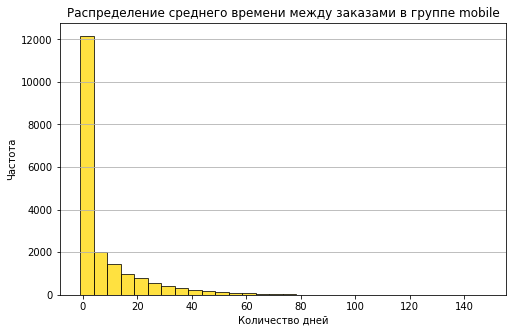

In [94]:
plt.figure(figsize=(8, 5))

# Строим гистограмму с помощью pandas через plot(kind='hist')
mobile_avg_days.plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                color='gold'
)

# Настраиваем оформление графика
plt.title('Распределение среднего времени между заказами в группе mobile')
plt.xlabel('Количество дней')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

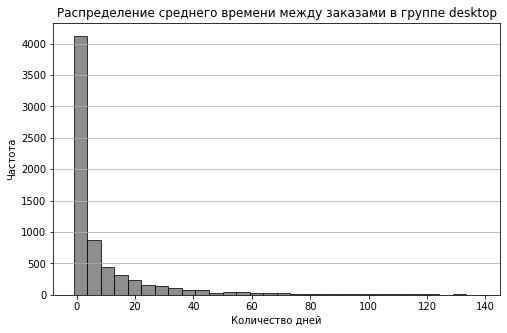

In [95]:
plt.figure(figsize=(8, 5))

# Строим гистограмму с помощью pandas через plot(kind='hist')
desktop_avg_days.plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                color='dimgrey'
)

# Настраиваем оформление графика
plt.title('Распределение среднего времени между заказами в группе desktop')
plt.xlabel('Количество дней')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

В группах наблюдается правосторонее распределение среднего времени между заказами. И выборки отличны по размеру более чем на 25%. С учетом распределения данных, для анализа выбран **U-test Манна-Уитни**

#### 4.2.4 Проведение статистического теста

Сформулируем нулевую и альтернативную гипотезы:

- **Нулевая гипотеза:** Среднее время между заказами в двух группах (mobile и desktop) не различаются
- **Альтернативная гипотеза:** Среднее время между заказами в группе mobile больше, чем в группе desktop, и это статистически значимо

In [96]:
# Проводим тест Манна-Уитни
alpha = 0.05

mw_test = mannwhitneyu(
    mobile_avg_days, # Выборка значений метрики для mobile
    desktop_avg_days, # Выборка значений метрики для desktop
    alternative='greater') # Выбираем одностороннюю гипотезу mobile > desktop


if mw_test.pvalue > alpha:
    print(f'pvalue={round(mw_test.pvalue,4)} > {alpha}')
    print('Нулевая гипотеза находит подтверждение. Распределения метрики в группах mobile и desktop равны')
    print('Интерпретация: среднее время между заказами в группах не различаются')
else:
    print(f'pvalue={round(mw_test.pvalue,4)} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения. Распределения метрики в группах mobile и desktop различаются')
    print('Интерпретация: среднее время между заказами в группе mobile больше')

pvalue=1.0 > 0.05
Нулевая гипотеза находит подтверждение. Распределения метрики в группах mobile и desktop равны
Интерпретация: среднее время между заказами в группах не различаются


### Промежуточный вывод

Для проверки гипотез о **разнице между пользователями мобильных и стационарных устройств** были проведены A/B - тесты с участием 2 групп: группа мобильных устройств состояла из **19509 пользователей**, группа стационарных устройств - из **6875 пользователей**. Между группами есть большая **разница в 64.76% пользователей**. В качестве целевой метрики для первой гипотезы выбрано **среднее количество заказов на пользователя**. Для второй гипотезы - **среднее время между заказами**.

**1. Первая гипотеза** о том, что среднее количество заказов на одного пользователя в группе mobile больше, чем в группе desktop **не нашла статистическое подтверждение** в рамках текущего эксперимента. Значение **p-value теста Уэлча оказалось равным 0.99**, поэтому у нас **нет оснований для отклонения нулевой гипотезы**, утверждающей равернство метрик между группами. На текущих данных **не удалось обнаружить статистически значимое различие между группами** пользователей мобильных и стационарных устройств.

**2. Вторая гипотеза** о том, что среднее время между заказами в группе mobile больше, чем в группе desktop **не нашла статистического подтверждения** в рамках текущего эксперимента. Значение **p-value = 1.0 > 0.05**, поэтому у нас **нет оснований для отклонения нулевой гипотезы**, утверждающей равернство метрик между группами. На текущих данных **не удалось обнаружить статистически значимого различия** среднего времени между заказами в группах пользователей мобильных и стационарных устройств.

<a id="итоговый-вывод"></a>
## 5. Общий вывод и рекомендации

<a id="основные-выводы"></a>
### 5.1 Основные выводы по анализу

В ходе исседования проведен **анализ 21422 пользователей, совершающих заказы на сервисе Яндекс-Афиша в период с 1 июня по 31 октября 2024 года**. Данные состояли из **двух основных датасетов с информацией о заказах** (в том числе, о типе устройств, с которого совершен заказ, выручке, количестве билетов, дате транзакции, особенности заказа) **и мероприятиях** (с уточнением типа мероприятия, региона и города проведения, площадки). А также **дополнительного датасета с информацией о конвертации валюты** из тенге в рубли.

#### Выводы по исследовательскому анализу данных:

**1. Сезонные изменения в заказах**
- **От июня к октябрю 2024г. наблюдается рост числа заказов**. **Лидирующие позиции** в оба сезона распределены **между концертами, театром и категорией "другое"**. В осенний период категории театр, спорт и ёлки более популярны, чем летом. Большинство пользователей предпочитает делать заказы с мобильных устройств. Осенью наблюдается рост спроса на "детские" категории билетов с возрастным рейтингом 0, 6, 12 по сравнению с летом. **В осенний период средняя выручка с одного билета выше у категорий стандап (+0,08), выставки (+0.05) и спорт (+0.01) по сравнению с летним периодом**, но понижаются значения средней выручки с одного билета в категориях: театр (-0.17), ёлки (-0.16), концерты (-0.07) и другое (-0.1)

**2. Осенняя активность пользователей**
- В осенний период наблюдается **постепенный рост количества заказов и активных пользователей с небольшими колебаниями по дням**. Наиболее высокие значения достигаются в первые дни месяца. При этом средняя выручка с билета достигает **наиболее низких значений (140-160 рублей) в пик пользовательской активности**. По дням недели наблюдается **спад пользовательской активности в выходные дни по сравнению с будними**. Наивысшие показатели достигаются со вторника по четверг. При этом, наибольшие показатели средней выручки с билета приходятся на период пониженной пользовательской активности.

**3. Популярные события и партнёры**
- **Каменевский регион и Североярскую область - регионы с наибольшим разнообразием мероприятий**. Распределение мероприятий между остальными регионами составляет не более 5% для каждого региона. **Явный лидер среди партнеров** по выручке (8.85 млн руб, 16% всей выручки), числу заказов (22089 заказов, 21% всех заказов) и количеству уникальных событий (3613 событий, 21% всех событий) - это **сервис "Лови билет!"**. В целом, **основная часть выручки и заказов распределена между первыми семью позициями ТОП-списка: их доля от всей выручки суммарно составляет 76,5%**. Таким образом на остальные 29 сервисов приходится менее 25% выручки. 

#### Выводы по статистическому анализу данных:

Для проверки гипотез о **разнице между пользователями мобильных и стационарных устройств** были проведены A/B - тесты с участием 2 групп: группа мобильных устройств состояла из **19509 пользователей**, группа стационарных устройств - из **6875 пользователей**. Между группами есть большая **разница в 64.76% пользователей**. В качестве целевой метрики для первой гипотезы выбрано **среднее количество заказов на пользователя**. Для второй гипотезы - **среднее время между заказами**.

**1. Первая гипотеза** о том, что среднее количество заказов на одного пользователя в группе mobile больше, чем в группе desktop **не нашла статистическое подтверждение** в рамках текущего эксперимента. Значение **p-value теста Уэлча оказалось равным 0.99**, поэтому у нас **нет оснований для отклонения нулевой гипотезы**. На текущих данных **не удалось обнаружить статистически значимое различие между группами** пользователей мобильных и стационарных устройств.

**2. Вторая гипотеза** о том, что среднее время между заказами в группе mobile больше, чем в группе desktop **не нашла статистического подтверждения** в рамках текущего эксперимента. Значение **p-value = 1.0 > 0.05**, поэтому у нас **нет оснований для отклонения нулевой гипотезы**. На текущих данных **не удалось обнаружить статистически значимого различия** среднего времени между заказами в группах пользователей мобильных и стационарных устройств.

Значения p-value сильно приближенное к 1 может означать обратный эффект первоначальных гипотез. Рекомендуется проверить двусторонним тестом.

<a id="рекомендации"></a>
### 5.2 Рекомендации на основе анализа

1. Запуск маркетинговых кампаний следует осуществлять в первые дни месяца, так как в эти дни пик пользовательского интереса. Желательно, в будние дни со вторника по четверг
2. Стоимость билетов аналогично следует повышать со вторника по четверг, а к выходным можно запускать акции, стимулирующие продажи.
3. Лидеру партнеру-сервису "Лови билет!" можно предложить сообые условия сотрудничества, так как от него приходит основная выручка.
4. В осенний период можно предлагать сервисом более дорогие билеты в момент покупки для повышения среднего чека. И дополнительно рекомендовать схожие мероприятия.